In [ ]:
import numpy as np
import pandas as pd

from scipy.sparse import load_npz

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [4]:
# Load TF-IDF features
X_train_tfidf = load_npz("../data/processed/X_train_tfidf.npz")
X_test_tfidf = load_npz("../data/processed/X_test_tfidf.npz")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training shape: (35751, 10000)
Testing shape: (8938, 10000)
Training labels: (35751,)
Testing labels: (8938,)


In [5]:
# Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

logistic_pred = logistic_model.predict(X_test_tfidf)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [6]:
# Check Logistic Regression accuracy
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")
    

Logistic Regression Accuracy: 99.44 %


In [7]:
# KNN
from sklearn.feature_extraction.text import TfidfVectorizer

data = pd.read_csv("../data/processed/cleaned_news.csv")

data["clean_content"] = data["clean_content"].fillna("")
data["clean_content"] = data["clean_content"].astype(str)

X = data["clean_content"]
y = data["label"]

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_knn, y_test_knn = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

knn_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words="english",
    sublinear_tf=True
)

X_train_knn = knn_vectorizer.fit_transform(X_train_text)
X_test_knn = knn_vectorizer.transform(X_test_text)

print("KNN training shape:", X_train_knn.shape)
print("KNN testing shape:", X_test_knn.shape)

KNN training shape: (35751, 3000)
KNN testing shape: (8938, 3000)


In [8]:
# Train KNN
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn_model.fit(X_train_knn, y_train_knn)

knn_pred = knn_model.predict(X_test_knn)

print("KNN training completed!")

KNN training completed!


In [9]:
knn_accuracy = accuracy_score(y_test_knn, knn_pred)

print("KNN Accuracy:",
      round(knn_accuracy * 100, 2), "%")

KNN Accuracy: 60.56 %


In [10]:
# Random Forest
rf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words="english",
    sublinear_tf=True
)

X_train_rf = rf_vectorizer.fit_transform(X_train_text)
X_test_rf = rf_vectorizer.transform(X_test_text)

print("Random Forest training shape:", X_train_rf.shape)
print("Random Forest testing shape:", X_test_rf.shape)

Random Forest training shape: (35751, 5000)
Random Forest testing shape: (8938, 5000)


In [11]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_knn)

rf_pred = rf_model.predict(X_test_rf)

print("Random Forest training completed!")

Random Forest training completed!


In [12]:
rf_accuracy = accuracy_score(y_test_knn, rf_pred)

print("Random Forest Accuracy:",
      round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 99.82 %


In [13]:
# Load Word2Vec embeddings
X_train_w2v = np.load("../data/processed/X_train_w2v.npy")
X_test_w2v = np.load("../data/processed/X_test_w2v.npy")

print("Word2Vec training shape:", X_train_w2v.shape)
print("Word2Vec testing shape:", X_test_w2v.shape)

Word2Vec training shape: (35751, 100)
Word2Vec testing shape: (8938, 100)


In [14]:
# MLP Neural Network
nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

nn_model.fit(X_train_w2v, y_train)

nn_pred = nn_model.predict(X_test_w2v)

print("Neural Network training completed!")

Neural Network training completed!


C:\Users\rahul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [15]:
nn_accuracy = accuracy_score(y_test, nn_pred)

print("Neural Network Accuracy:",
      round(nn_accuracy * 100, 2), "%")

Neural Network Accuracy: 98.23 %


In [16]:
# Compare all models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        rf_accuracy,
        nn_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Accuracy (%)
0,Random Forest,0.998210,99.820989
1,Logistic Regression,0.994406,99.440591
2,Neural Network,0.982323,98.232267
3,KNN,0.605616,60.561647


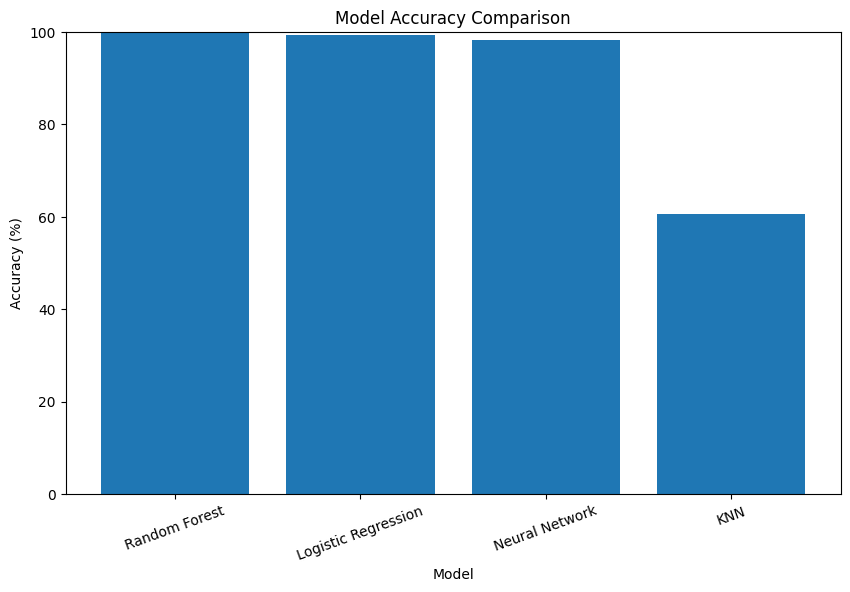

In [17]:
# Plot comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.show()

In [18]:
# Save model results
results.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!
